<a href="https://colab.research.google.com/github/ib75zr/StockAI-Sentiment/blob/main/AISDS_StockAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Powered Stock Decision System using Deep Learning and Real-Time News Sentiment Analysis


Stock : Saudi Aramco 2222

Data : Yahoo Finance (yfinance - auto downloaded historical data)

News : Google News RSS (Web Scraping)

Model : LSTM Neural Network (Time Series Forecasting)

NLP : FinBERT (Financial Sentiment Analysis)

Features:  Historical Price Data (Open, High, Low, Close, Volume) + News Sentiment Scores (Time-Weighted)


Output : BUY / SELL / HOLD + Confidence Score

...

In [ ]:
!pip install yfinance beautifulsoup4 requests lxml transformers xgboost scikit-learn --quiet

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from bs4 import BeautifulSoup
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D

from transformers import pipeline
from urllib.parse import quote

In [ ]:
TICKER = "2222.SR"

data = yf.download(TICKER, start="2022-01-01", end="2026-04-27", auto_adjust=True)
data = data.reset_index()

data = data[['Date','Open','High','Low','Close','Volume']]
data.columns = ['Date','Open','High','Low','Price','Vol.']
data.dropna(inplace=True)

print("\n")
print("\n STOCK DATA SAMPLE:")
print(data.head(5).to_string(index=False))

print("\n")
print("\n LAST 5 ROWS:")
print(data.tail(5).to_string(index=False))

print("\n")
print("\n DATA INFO:")
print(data.describe())

[*********************100%***********************]  1 of 1 completed




 STOCK DATA SAMPLE:
      Date      Open      High       Low     Price    Vol.
2022-01-02 24.115029 24.115029 23.980120 23.980120 2644521
2022-01-03 23.946390 24.148754 23.946390 24.047571 3409916
2022-01-04 24.013849 24.081303 23.980122 24.013849 2423144
2022-01-05 23.980119 24.148756 23.980119 24.115028 2979819
2022-01-06 24.013849 24.047575 23.912666 23.912666 3839851



 LAST 5 ROWS:
      Date      Open      High       Low     Price     Vol.
2026-04-19 27.299999 27.379999 27.200001 27.200001  7738516
2026-04-20 27.299999 27.379999 27.139999 27.200001 10619388
2026-04-21 27.200001 27.260000 27.080000 27.160000  9428400
2026-04-22 27.160000 27.280001 27.139999 27.260000  9583278
2026-04-23 27.299999 27.440001 27.219999 27.219999 13039444



 DATA INFO:
                                Date         Open         High          Low  \
count                           1073  1073.000000  1073.000000  1073.000000   
mean   2024-02-27 19:50:22.926374656    26.336793    26.488287    26.1676

In [ ]:
sentiment_model = pipeline("sentiment-analysis", model="ProsusAI/finbert")

def sentiment_score(text):
    try:
        r = sentiment_model(str(text))[0]
        if r["label"] == "positive":
            return r["score"]
        elif r["label"] == "negative":
            return -r["score"]
        return 0
    except:
        return 0

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def strip_tz(dt_index):
    dt_index = pd.to_datetime(dt_index)
    if dt_index.tz is not None:
        return dt_index.tz_convert(None)
    return dt_index

def strip_tz_scalar(dt):
    dt = pd.to_datetime(dt)
    if dt.tzinfo is not None:
        return dt.tz_convert(None).normalize()
    return dt.normalize()

def compute_impact_score(news_df, data):

    price_data = data.set_index('Date')[['Price', 'Vol.']].copy()
    price_data.index = strip_tz(price_data.index)

    price_data['Vol_MA10'] = price_data['Vol.'].rolling(10).mean()

    impact_scores = []

    for _, row in news_df.iterrows():
        news_date = strip_tz_scalar(row['Date'])

        future_dates = price_data.index[price_data.index > news_date]
        past_dates   = price_data.index[price_data.index <= news_date]

        if len(future_dates) == 0 or len(past_dates) == 0:
            impact_scores.append(0)
            continue

        next_day = future_dates[0]
        prev_day = past_dates[-1]

        price_before = price_data.loc[prev_day, 'Price']
        price_after  = price_data.loc[next_day, 'Price']

        # change price
        price_change_pct = (price_after - price_before) / (price_before + 1e-9)
        #the amaunt of the      in the AVG
        vol_after  = price_data.loc[next_day, 'Vol.']
        vol_ma     = price_data.loc[next_day, 'Vol_MA10']
        vol_ratio  = (vol_after / (vol_ma + 1e-9)) - 1
        vol_factor = np.clip(vol_ratio, -1, 1)
        #is the vector of news equls the price vector
        finbert_sign    = np.sign(row['Sentiment'])
        price_sign      = np.sign(price_change_pct)
        direction_match = 1 if finbert_sign == price_sign else -1

        # Impact Score
        raw_impact = (
            np.clip(price_change_pct * 10, -1, 1) * 0.50 +
            vol_factor                             * 0.30 +
            direction_match                        * 0.20
        )

        impact_scores.append(np.clip(raw_impact, -1, 1))

    news_df = news_df.copy()
    news_df['ImpactScore'] = impact_scores
    return news_df


print("✓ Impact Score function ready")

✓ Impact Score function ready


In [ ]:
def get_news():

    query = quote("Saudi Aramco stock")
    url = f"https://news.google.com/rss/search?q={query}&hl=en-US&gl=US&ceid=US:en"

    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(url, headers=headers)

    soup = BeautifulSoup(resp.content, "xml")
    items = soup.find_all("item")

    articles = []

    for item in items[:100]:
        title = item.title.text if item.title else ""
        link  = item.link.text if item.link else ""
        pub   = item.pubDate.text if item.pubDate else ""

        try:
            date = pd.to_datetime(pub)
        except:
            continue

        articles.append([date, title, link])

    news_df = pd.DataFrame(articles, columns=["Date","Title","Link"])

    news_df = news_df.drop_duplicates(subset=["Title"])
    news_df["Sentiment"] = news_df["Title"].apply(sentiment_score)

    return news_df


news_df = get_news()


print("\n NEWS DATA SAMPLE:")
print(news_df.head(5).to_string(index=False))

print("\n LATEST NEWS:")
latest = news_df.sort_values("Date", ascending=False).head(5)
for i, row in latest.iterrows():
    print(f"- {row['Date'].date()} | {row['Title']}")
    print(f"  Link: {row['Link']}")
    print(f"  Sentiment: {row['Sentiment']:.3f}\n")


 NEWS DATA SAMPLE:
               Date                                                                                Title                                                                                                                                                                                                                                                                                           Link  Sentiment
2026-04-06 07:00:00                    Saudi Arabia charges record premium for its oil - Financial Times                                                              https://news.google.com/rss/articles/CBMihAFBVV95cUxNNGZiWUtHN0o5QXowcTdFSDNZZUZwRVpGYzB2dFp3dGpyVkJCak5WbWZxd1VHT3hWUXY4WlloaHA0bzI4cHpLQS1QektoSmlwd1ZhMm9VQjlIenY1TjVueFVVSDdYcTd6MVNTSF9NYjVjdzJxS1hxMDlyUWcwVFNqem03TTA?oc=5   0.698989
2026-04-01 07:00:00                                                            Saudi Aramco - Britannica                                                                      

In [ ]:
news_df = compute_impact_score(news_df, data)

print("\n IMPACT SCORE SAMPLE (Latest 5 News):")
latest_impact = news_df.sort_values('Date', ascending=False).head(5)
for _, row in latest_impact.iterrows():
    bar = '█' * int(abs(row['ImpactScore']) * 10)
    sign = '+' if row['ImpactScore'] >= 0 else '-'
    print(f"  [{sign}{bar:<10}] Impact={row['ImpactScore']:+.3f} | FinBERT={row['Sentiment']:+.3f}")
    print(f"   {row['Title'][:80]}")
    print()


 IMPACT SCORE SAMPLE (Latest 5 News):
  [+███       ] Impact=+0.368 | FinBERT=+0.699
   Saudi Arabia charges record premium for its oil - Financial Times

  [-█         ] Impact=-0.200 | FinBERT=-0.395
   Saudi Stocks End March Higher amid Geopolitical Tensions - Asharq Al-Awsat | Exp

  [-█         ] Impact=-0.200 | FinBERT=+0.000
   Saudi Aramco - Britannica

  [-██        ] Impact=-0.275 | FinBERT=-0.961
   Saudi Aramco shares down 1% in early trade - LSEG - marketscreener.com

  [-██        ] Impact=-0.247 | FinBERT=+0.000
   Saudi Aramco Stock Rally: Geopolitical Crisis Drives Gains - Discovery Alert



In [ ]:
daily_sentiment = []
daily_impact = []
daily_links = []

news_df["Date"] = pd.to_datetime(news_df["Date"]).dt.tz_localize(None).dt.normalize()
data["Date"]    = pd.to_datetime(data["Date"]).dt.tz_localize(None).dt.normalize()

for d in data["Date"]:

    mask = (news_df["Date"] >= d - pd.Timedelta(days=7)) & \
           (news_df["Date"] <= d + pd.Timedelta(days=1))
    past = news_df[mask]

    if len(past) > 0:

        days_diff = (d - past["Date"]).dt.days.clip(lower=0) + 1
        weights = np.exp(-days_diff / 10)

        sent = np.average(past["Sentiment"], weights=weights)
        impact = np.average(past["ImpactScore"], weights=weights)
        links = past["Link"].tail(3).tolist()

    else:
        sent = 0
        impact = 0
        links = []

    daily_sentiment.append(sent)
    daily_impact.append(impact)
    daily_links.append(links)

data["Sentiment"] = daily_sentiment
data["ImpactScore"] = daily_impact

print("\n LAST COMBINED DATA:")
print(data[['Date','Open','High','Low','Price','Vol.','Sentiment','ImpactScore']].tail(5).to_string(index=False))


 LAST COMBINED DATA:
      Date      Open      High       Low     Price     Vol.  Sentiment  ImpactScore
2026-04-19 27.299999 27.379999 27.200001 27.200001  7738516        0.0          0.0
2026-04-20 27.299999 27.379999 27.139999 27.200001 10619388        0.0          0.0
2026-04-21 27.200001 27.260000 27.080000 27.160000  9428400        0.0          0.0
2026-04-22 27.160000 27.280001 27.139999 27.260000  9583278        0.0          0.0
2026-04-23 27.299999 27.440001 27.219999 27.219999 13039444        0.0          0.0


In [ ]:
features = ['Open','High','Low','Price','Vol.','Sentiment','ImpactScore']

SEQ   = 60
SPLIT = int((len(data) - SEQ) * 0.8)

scaler = MinMaxScaler()
scaler.fit(data[features].iloc[:SPLIT + SEQ])
scaled = scaler.transform(data[features])

X, y = [], []

for i in range(SEQ, len(scaled)):
    X.append(scaled[i-SEQ:i])
    y.append(scaled[i, 3])

X = np.array(X)
y = np.array(y)

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Features     : {features}")
print(f"Input shape  : {X.shape}")

Features     : ['Open', 'High', 'Low', 'Price', 'Vol.', 'Sentiment', 'ImpactScore']
Input shape  : (1013, 60, 7)


In [ ]:
# This is a Models

es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
results = {}  # save all models hare


# 1- LSTM
print("▶ Training LSTM...")
lstm_model = Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.fit(X_train, y_train, epochs=20, batch_size=32,
               validation_split=0.1, callbacks=[es], verbose=0)
results["LSTM"] = lstm_model
print("  ✓ LSTM done")


# 2- GRU
print("▶ Training GRU...")
gru_model = Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    GRU(128, return_sequences=True),
    Dropout(0.3),
    GRU(64),
    Dropout(0.3),
    Dense(1)
])
gru_model.compile(optimizer="adam", loss="mse")
gru_model.fit(X_train, y_train, epochs=20, batch_size=32,
              validation_split=0.1, callbacks=[es], verbose=0)
results["GRU"] = gru_model
print("  ✓ GRU done")


# 3- Transformer
print("▶ Training Transformer...")
tf_input = Input(shape=(X.shape[1], X.shape[2]))
tf_x = MultiHeadAttention(num_heads=4, key_dim=32)(tf_input, tf_input)
tf_x = LayerNormalization()(tf_x)
tf_x = GlobalAveragePooling1D()(tf_x)
tf_x = Dense(64, activation="relu")(tf_x)
tf_x = Dropout(0.3)(tf_x)
tf_out = Dense(1)(tf_x)
transformer_model = Model(tf_input, tf_out)
transformer_model.compile(optimizer="adam", loss="mse")
transformer_model.fit(X_train, y_train, epochs=20, batch_size=32,
                      validation_split=0.1, callbacks=[es], verbose=0)
results["Transformer"] = transformer_model
print("  ✓ Transformer done")


# 4- XGBoost
print("▶ Training XGBoost...")
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d  = X_test.reshape(X_test.shape[0], -1)
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05,
                          max_depth=6, subsample=0.8,
                          colsample_bytree=0.8, random_state=42,
                          verbosity=0)
xgb_model.fit(X_train_2d, y_train)
results["XGBoost"] = xgb_model
print("  ✓ XGBoost done")


# 5- Random Forest
print("▶ Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10,
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train_2d, y_train)
results["RandomForest"] = rf_model
print("  ✓ Random Forest done")


print("\n All 5 models trained successfully!")

▶ Training LSTM...
  ✓ LSTM done
▶ Training GRU...
  ✓ GRU done
▶ Training Transformer...
  ✓ Transformer done
▶ Training XGBoost...
  ✓ XGBoost done
▶ Training Random Forest...
  ✓ Random Forest done

 All 5 models trained successfully!


In [ ]:
# And this Prediction

price_scaler = MinMaxScaler()
train_size = split + SEQ
price_scaler.fit(data[["Price"]].iloc[:train_size])

def inv(arr):
    # inverse transform helper
    return price_scaler.inverse_transform(arr.reshape(-1, 1)).flatten()

real_inv = inv(y_test)

# LSTM
lstm_pred   = inv(lstm_model.predict(X_test, verbose=0).flatten())

# GRU
gru_pred    = inv(gru_model.predict(X_test, verbose=0).flatten())

# Transformer
trans_pred  = inv(transformer_model.predict(X_test, verbose=0).flatten())

# XGBoost
xgb_pred    = inv(xgb_model.predict(X_test_2d).flatten())

# Random Forest
rf_pred     = inv(rf_model.predict(X_test_2d).flatten())



all_preds = {
    "LSTM"        : lstm_pred,
    "GRU"         : gru_pred,
    "Transformer" : trans_pred,
    "XGBoost"     : xgb_pred,
    "RandomForest": rf_pred,
}

print("✓ All predictions ready")

✓ All predictions ready


In [ ]:
# Evaluation And Ensemble

metrics = {}

print(f"  {'Model':<15} {'RMSE':>8} {'MAE':>8} {'MAPE%':>8}")
print("  " + "─"*42)

for name, pred in all_preds.items():
    n = min(len(real_inv), len(pred))
    r = real_inv[:n]
    p = pred[:n]
    rmse = np.sqrt(mean_squared_error(r, p))
    mae  = mean_absolute_error(r, p)
    mape = np.mean(np.abs((r - p) / (r + 1e-9))) * 100
    metrics[name] = {"rmse": rmse, "mae": mae, "mape": mape, "pred": pred}
    print(f"  {name:<15} {rmse:>8.3f} {mae:>8.3f} {mape:>7.2f}%")

# Weighted Ensemble
rmse_vals   = np.array([metrics[m]["rmse"] for m in all_preds])
inv_rmse    = 1 / (rmse_vals + 1e-9)
weights_ens = inv_rmse / inv_rmse.sum()

min_len = min(len(p) for p in all_preds.values())
ensemble_pred = np.zeros(min_len)
for w, pred in zip(weights_ens, all_preds.values()):
    ensemble_pred += w * pred[:min_len]

real_ens = real_inv[:min_len]
ens_rmse = np.sqrt(mean_squared_error(real_ens, ensemble_pred))
ens_mae  = mean_absolute_error(real_ens, ensemble_pred)
ens_mape = np.mean(np.abs((real_ens - ensemble_pred) / (real_ens + 1e-9))) * 100
metrics["Ensemble"] = {"rmse": ens_rmse, "mae": ens_mae, "mape": ens_mape, "pred": ensemble_pred}

print("  " + "─"*42)
print(f"  {'Ensemble':<15} {ens_rmse:>8.3f} {ens_mae:>8.3f} {ens_mape:>7.2f}%  ← final")

# best model
best_model_name = min(metrics, key=lambda m: metrics[m]["rmse"])
print(f"\n  Best Model: {best_model_name} (RMSE={metrics[best_model_name]['rmse']:.3f})")


  Model               RMSE      MAE    MAPE%
  ──────────────────────────────────────────
  LSTM               0.533    0.411    1.67%
  GRU                0.340    0.241    0.98%
  Transformer        1.073    0.937    3.77%
  XGBoost            0.404    0.323    1.33%
  RandomForest       0.373    0.299    1.22%
  ──────────────────────────────────────────
  Ensemble           0.349    0.293    1.20%  ← final

  Best Model: GRU (RMSE=0.340)


In [ ]:
# Decision Engine

# Future Prediction
last_seq_dl  = scaled[-SEQ:].reshape(1, SEQ, len(features))
last_seq_ml  = scaled[-SEQ:].reshape(1, -1)

future_preds = {
    "LSTM"        : price_scaler.inverse_transform(lstm_model.predict(last_seq_dl, verbose=0))[0][0],
    "GRU"         : price_scaler.inverse_transform(gru_model.predict(last_seq_dl, verbose=0))[0][0],
    "Transformer" : price_scaler.inverse_transform(transformer_model.predict(last_seq_dl, verbose=0))[0][0],
    "XGBoost"     : float(inv(xgb_model.predict(last_seq_ml))),
    "RandomForest": float(inv(rf_model.predict(last_seq_ml))),
}

last_pred = (
    weights_ens[0] * future_preds["LSTM"]         +
    weights_ens[1] * future_preds["GRU"]           +
    weights_ens[2] * future_preds["Transformer"]   +
    weights_ens[3] * future_preds["XGBoost"]       +
    weights_ens[4] * future_preds["RandomForest"]
)

last_real = float(data["Price"].iloc[-1])

sent_mean   = np.mean(data["Sentiment"].tail(5))
impact_mean = np.mean(data["ImpactScore"].tail(5))

diff = last_pred - last_real
vol  = data["Price"].tail(30).std()

combined_signal = sent_mean * 0.4 + impact_mean * 0.6

if diff > vol * 0.5 and combined_signal > 0.2:
    decision = "STRONG BUY"
elif diff > vol * 0.3 and combined_signal > 0.15:
    decision = "BUY"
elif diff < -vol * 0.5 and combined_signal < -0.2:
    decision = "STRONG SELL"
elif diff < -vol * 0.3 and combined_signal < -0.15:
    decision = "SELL"
else:
    decision = "HOLD"

price_change_pct = abs(diff) / (last_real + 1e-9) * 100
sentiment_factor = min(1.0, abs(sent_mean) / 0.5)
impact_factor    = min(1.0, abs(impact_mean) / 0.5)
model_accuracy   = max(0, 1 - (vol / last_real))

base_confidence = (
    price_change_pct * 35 +
    sentiment_factor * 20 +
    impact_factor    * 20 +
    model_accuracy   * 25
)

decision_weight = {
    "STRONG BUY"  : 1.0,
    "BUY"         : 0.8,
    "HOLD"        : 0.4,
    "SELL"        : 0.8,
    "STRONG SELL" : 1.0,
}

confidence = min(92, base_confidence * decision_weight[decision])

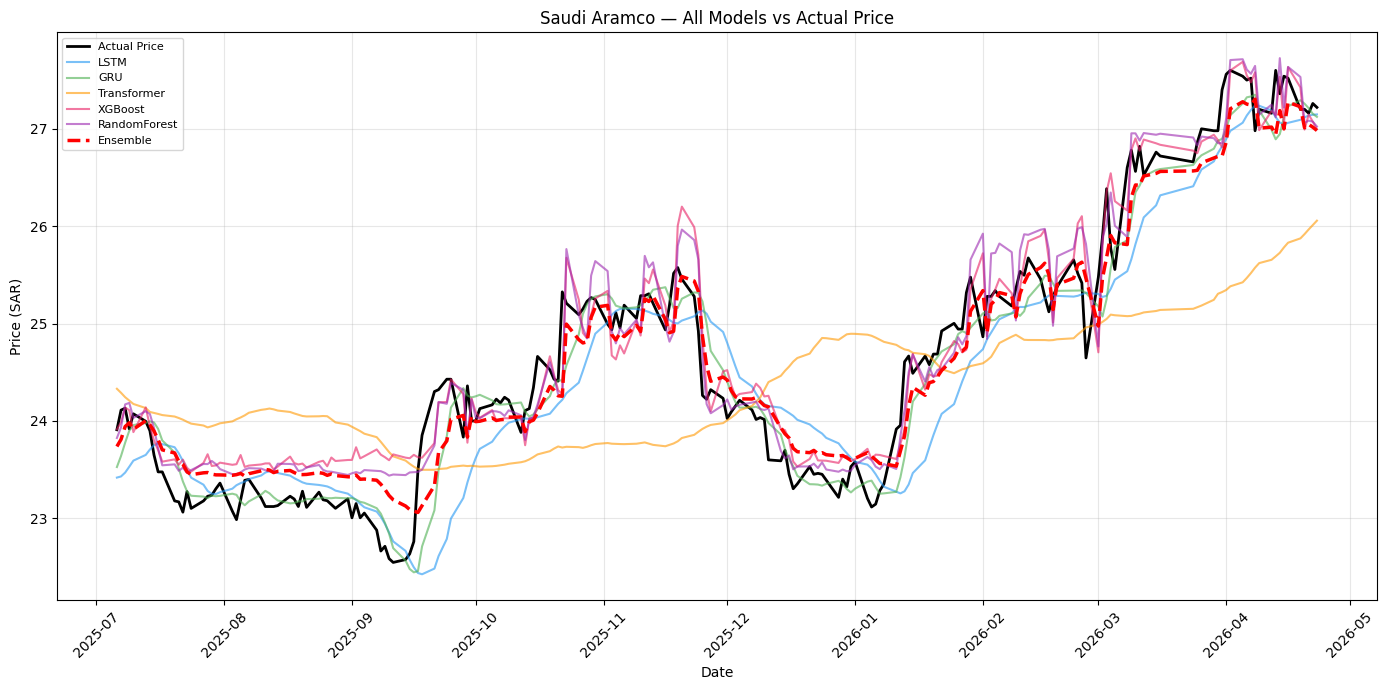

In [ ]:
dates = data["Date"].iloc[-min_len:].reset_index(drop=True)

plt.figure(figsize=(14, 7))
plt.plot(dates, real_ens, label="Actual Price", color="black", linewidth=2)

colors = ["#2196F3","#4CAF50","#FF9800","#E91E63","#9C27B0"]
for (name, pred), color in zip(all_preds.items(), colors):
    plt.plot(dates, pred[:min_len], label=name, alpha=0.6, color=color)

plt.plot(dates, ensemble_pred, label="Ensemble", color="red",
         linewidth=2.5, linestyle="--")

plt.title("Saudi Aramco — All Models vs Actual Price")
plt.ylabel("Price (SAR)")
plt.xlabel("Date")
plt.legend(loc="upper left", fontsize=8)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

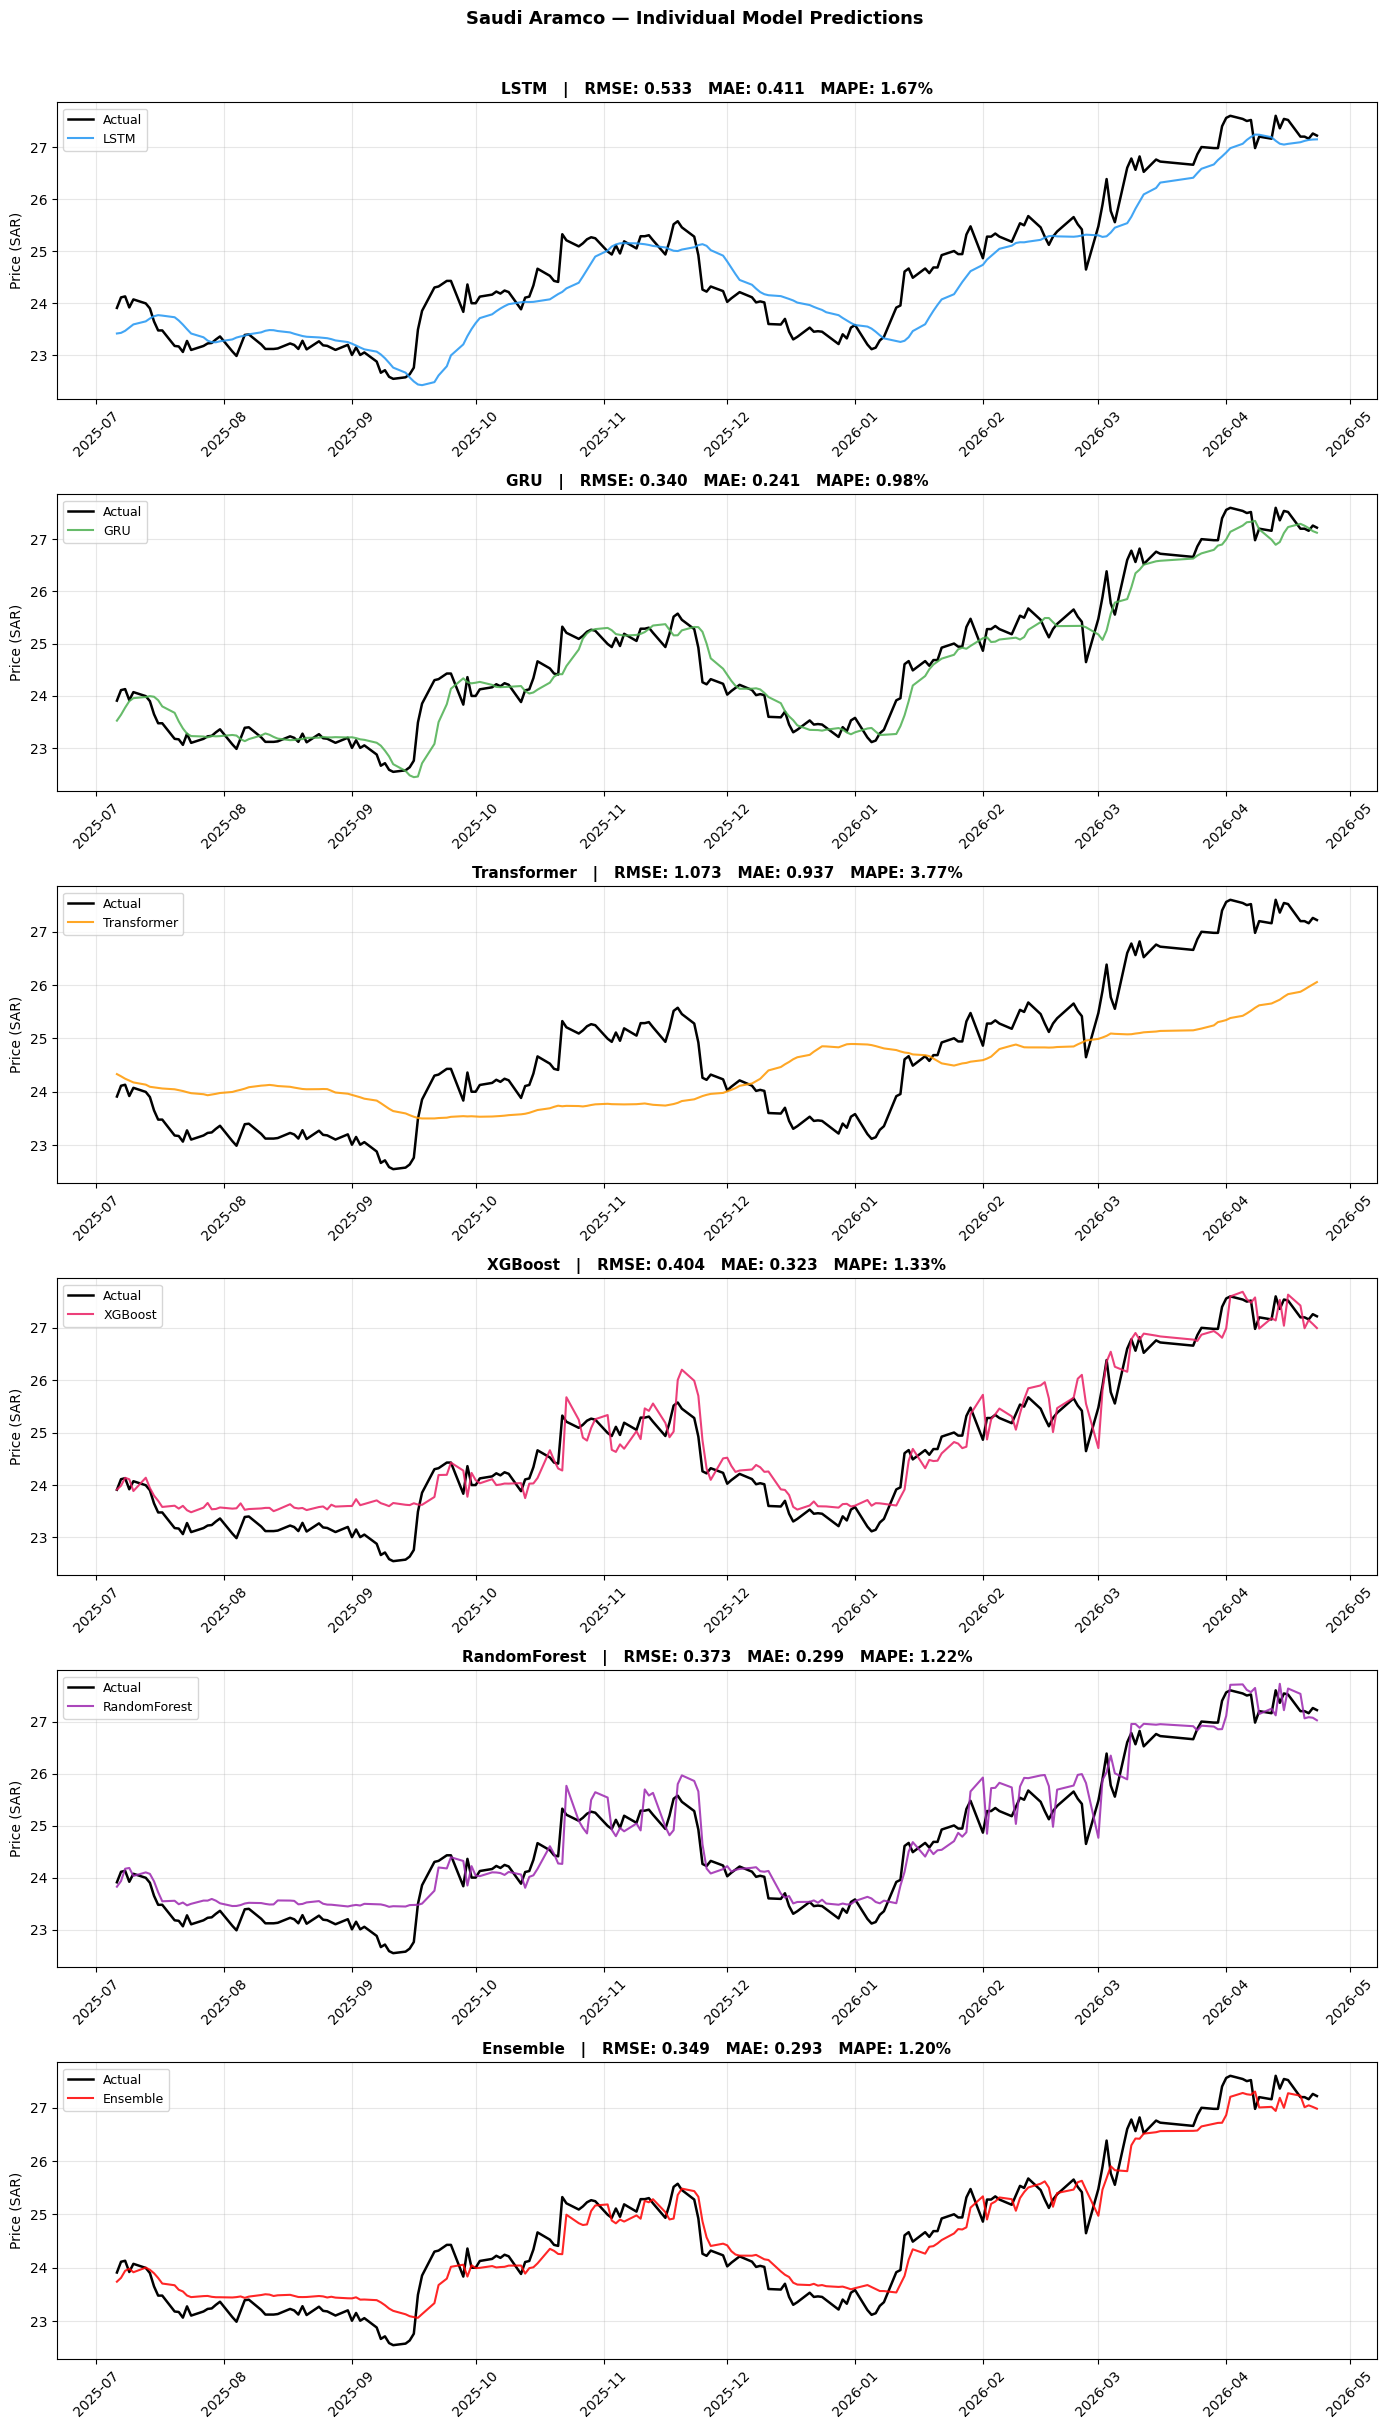

In [ ]:
dates = data["Date"].iloc[-min_len:].reset_index(drop=True)

colors = {
    "LSTM" : "#2196F3",
    "GRU" : "#4CAF50",
    "Transformer" : "#FF9800",
    "XGBoost" : "#E91E63",
    "RandomForest" : "#9C27B0",
    "Ensemble" : "red",
}

all_preds_with_ensemble = {**all_preds, "Ensemble": ensemble_pred}

fig, axes = plt.subplots(len(all_preds_with_ensemble), 1, figsize=(14, 4 * len(all_preds_with_ensemble)))

for ax, (name, pred) in zip(axes, all_preds_with_ensemble.items()):
    n = min(len(dates), len(pred))
    m = metrics[name]

    ax.plot(dates[:n], real_ens[:n], label="Actual",  color="black", linewidth=1.8)
    ax.plot(dates[:n], pred[:n],     label=name,      color=colors.get(name, "gray"), linewidth=1.5, alpha=0.85)

    ax.set_title(f"{name}   |   RMSE: {m['rmse']:.3f}   MAE: {m['mae']:.3f}   MAPE: {m['mape']:.2f}%",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("Price (SAR)")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Saudi Aramco — Individual Model Predictions", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# REPORT

print(f"\n")
print("AI STOCK REPORT — Saudi ARAMCO 2222")


print("\n REAL DATA")
print(f"- Last Real Price : {last_real:.2f} SAR")
print(f"- Sentiment Avg   : {sent_mean:.3f}")
print(f"- Impact Score      : {impact_mean:+.3f}")
print(f"- Combined Signal   : {combined_signal:+.3f}")

print("\n PREDICTION DATA")
print(f"- Predicted Price : {last_pred:.2f} SAR")
print(f"- Difference      : {diff:.2f} SAR")
print(f"- Confidence      : {confidence:.1f}%")

print("\n FINAL RECOMMENDATION")
print(f"   >>> {decision} <<<")

print("\n")

print("\n NEWS SOURCES (Latest Articles)")
latest_news = news_df.sort_values("Date", ascending=False).head(5)

for i, row in latest_news.iterrows():
    bar = '█' * int(abs(row['ImpactScore']) * 10)
    sign = '+' if row['ImpactScore'] >= 0 else '-'
    print(f"  [{sign}{bar:<10}] Impact={row['ImpactScore']:+.3f} | {row['Title'][:60]}")
    print(f"   {row['Link']}")
    print()



AI STOCK REPORT — Saudi ARAMCO 2222

 REAL DATA
- Last Real Price : 27.22 SAR
- Sentiment Avg   : 0.000
- Impact Score      : +0.000
- Combined Signal   : +0.000

 PREDICTION DATA
- Predicted Price : 26.96 SAR
- Difference      : -0.26 SAR
- Confidence      : 23.1%

 FINAL RECOMMENDATION
   >>> HOLD <<<



 NEWS SOURCES (Latest Articles)
  [+███       ] Impact=+0.368 | Saudi Arabia charges record premium for its oil - Financial 
   https://news.google.com/rss/articles/CBMihAFBVV95cUxNNGZiWUtHN0o5QXowcTdFSDNZZUZwRVpGYzB2dFp3dGpyVkJCak5WbWZxd1VHT3hWUXY4WlloaHA0bzI4cHpLQS1QektoSmlwd1ZhMm9VQjlIenY1TjVueFVVSDdYcTd6MVNTSF9NYjVjdzJxS1hxMDlyUWcwVFNqem03TTA?oc=5

  [-█         ] Impact=-0.200 | Saudi Stocks End March Higher amid Geopolitical Tensions - A
   https://news.google.com/rss/articles/CBMiogFBVV95cUxQMHNWNGJJRktiQ1hkeHhqUjZzaDNEdG5mWEZDa050aUJWVzRMNkw2MnA2TWdxbG9aYkxTM3dlTFpfUmlsbFpWX2dNbGtOeThjeFp4cWRYeWJYREQ3SUt3WHdWLTJqZnJtSUJOWXV0R2lHa19lbnUwSDFmRlJQQ1F0WS14UlAydnFEY0dTN0xBc3RZWV

In [ ]:
model_names = list(all_preds.keys())
print("\n ENSEMBLE WEIGHTS")
for name, w in zip(model_names, weights_ens):
    bar = "█" * int(w * 100)
    print(f"  {name:<15} {w*100:>5.1f}%  {bar}")


 ENSEMBLE WEIGHTS
  LSTM             17.2%  █████████████████
  GRU              27.0%  ██████████████████████████
  Transformer       8.5%  ████████
  XGBoost          22.7%  ██████████████████████
  RandomForest     24.6%  ████████████████████████
